Make predictions for a simple regulatory constraint model on human chromosome 22.

In [2]:
import time
import bgshr
import numpy as np
import pandas
import matplotlib.pylab as plt

In [20]:
# Paths to input data files
lookup_tbl_file = "data/lookup_tbl_equilibrium.csv.gz"
rec_map_file = "data/YRI_recombination_map_hapmap_format_hg38_chr_22.txt.gz"
mut_tbl_file = "data/roulette_tbl_chr22.csv.gz"
element_files = [
    "data/cds_merged_chr22.bed.gz",
    "data/promoters_chr22.bed.gz"]

# Define parameters
Ne = 27000
# The Kim et al (2017) DFE, inferred for nonsynonymous CDS, and the promoter
# DFE from Barroso et al (2026).
# We place 30.2% of mass of the Kim DFE on s = 0 to account for synonymous mutations.
dfes = [
    {"type": "gamma_neutral", "shape": 0.215, "scale": 0.023981, "p_neu": 0.302},
    {"type": "gamma", "shape": 0.110826, "scale": 0.000500}]

# Focal sites for diversity reduction prediction.
L = 50818468
spacing = 10000
xs = np.arange(spacing // 2, L, spacing // 2)

In [7]:
# Load and scale the lookup table to the target Ne.
df = pandas.read_csv(lookup_tbl_file)
df = bgshr.Util.scale_lookup_table(df, Ne)
df = bgshr.Util.fill_in_lookup_table(df)

# Extend the lookup table using classic BGS
min_s = np.min(df["s"])
ss_extend = -np.logspace(0, np.log10(-min_s), 17)[:-1]
df = bgshr.ClassicBGS.extend_lookup_table(df, ss_extend)

# Add a column with genetic map distances to the table and get splines
df = bgshr.Util.convert_lookup_table_to_morgans(df)
splines = bgshr.Util.generate_linear_splines(df)[2]

In [21]:
# Load other data
rmap = bgshr.Util.load_recombination_map(rec_map_file, L)

mut_df = pandas.read_csv(mut_tbl_file)
columns = mut_df.columns
tbl_intervals = np.stack((mut_df[columns[1]], 
    mut_df[columns[2]]), axis=1).astype(np.int64)
values = np.array(mut_df[columns[4]])
umap = bgshr.Util.build_site_map(tbl_intervals, values)
umap = np.ma.array(umap, mask=np.zeros(len(umap)))

# Set up windows to aggregate constrained sites and calculate window mutation rates.
elements = [bgshr.Util.read_bedfile(f) for f in element_files]
elements = bgshr.Util.resolve_elements(elements, verbose=True)
ws = 1000
windows = np.stack([np.arange(0, L - ws, ws), np.arange(ws, L, ws)], axis=1)
U_arrs = [bgshr.Util.compute_window_mutation_rates(windows, elems, umap)[0]
          for elems in elements]
windows, U_arrs = bgshr.Util.filter_empty_windows(windows, U_arrs)

[26-06-25 12:05:32] removed 159 redundant sites from element class 1


In [22]:
# Run two rounds of interference correction
B_arrs = bgshr.Predict.interference_Bvals(
    xs,
    splines,
    windows=windows,
    U_arrs=U_arrs,
    rmap=rmap,
    max_dist=0.1,
    dfes=dfes,
    n_corrs=2,
    chunk_size=100,
    n_cores=8,
    verbose=True)

[26-06-25 12:05:36] completed initial B-prediction
[26-06-25 12:05:56] completed interference correction 1
[26-06-25 12:06:16] completed interference correction 2


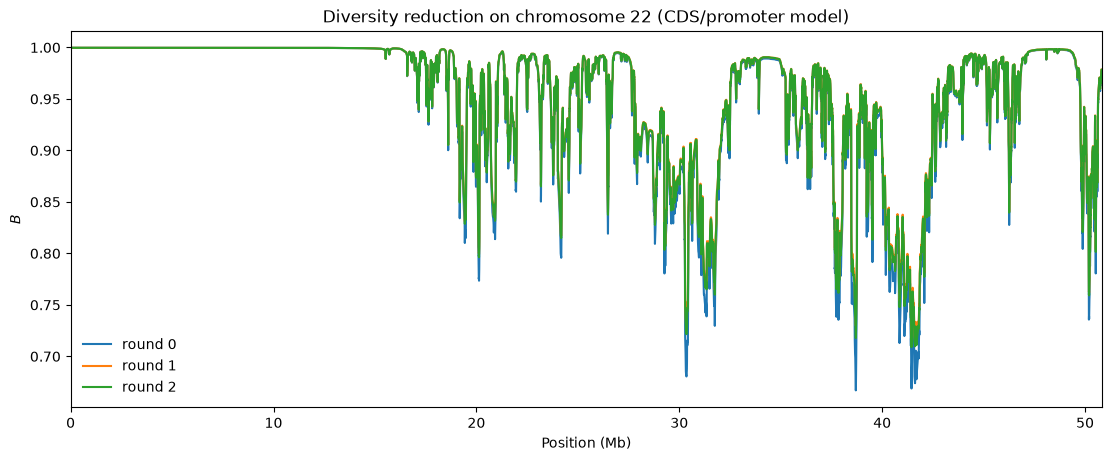

In [23]:
fig, ax = plt.subplots(figsize=(11, 4.5), layout="constrained")
ax.plot(xs, B_arrs[0], label="round 0")
ax.plot(xs, B_arrs[1], label="round 1")
ax.plot(xs, B_arrs[2], label="round 2")
ax.legend(framealpha=0)
ax.set_xlim(0, L)
ax.set_title("Diversity reduction on chromosome 22 (CDS/promoter model)")
ax.set_ylabel("$B$")
ax.set_xlabel("Position (Mb)")
ax.set_xticks([0, 1e7, 2e7, 3e7, 4e7, 5e7], [0, 10, 20, 30, 40, 50])